# Label switching: relabelling the draws of a mixture posterior

A mixture's likelihood does not change when its components are renamed, and
under an exchangeable prior neither does its posterior, so a chain that
mixes visits every naming of every mode. A summary over draws --- a posterior
mean, a per-observation allocation --- then averages different components
together. This notebook draws two mixture posteriors with three samplers,
puts every draw in a random naming whose permutation is recorded, and asks
each of the seven relabelling methods of `sample.relabel` to undo it (issue
#964). Each method is read against three things it never sees: the planted
permutations, the component that generated each observation, and the
generating parameters.

Terms the rest uses:

- **Allocation** $z_i$: the component observation $i$ is assigned to in one
  draw. **Allocation probabilities** $p_{ik}$: its responsibilities at that
  draw's parameters, the input of STEPHENS and ECR-ITERATIVE-2.
- **Relabelling**: one permutation per draw. `permutations[t, k]` names the
  component of draw $t$ that becomes label $k$ (`sample.relabel`'s one
  convention).
- **Planted recovery**: the share of draws put back in one common naming
  after a known random permutation was applied to each; 1.0 is every draw.
- **Accuracy**: the share of observations whose relabelled point allocation,
  the argmax of the mean relabelled probabilities, is their generating
  component, up to one renaming of the whole fit. Its ceiling is the Bayes
  rule at the generating parameters, computed below.

STEPHENS is the default of `relabel`: it reads only the allocation
probabilities, which any emission family gives, needs no pivot, and lowers a
stated objective at every pass.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from sal.emissions import CountPairEmission, GaussianEmission
from sal.opt.emission_mixture import EmissionMixtureObjective
from sal.opt.mixture import GaussianMixtureObjective, responsibilities
from sal.qa.style import notebook_style
from sal.sample import hmc
from sal.sample.langevin import mala
from sal.sample.mixture_gibbs import (
    GaussianMixturePrior,
    gibbs_gaussian_mixture,
)
from sal.sample.relabel import (
    RelabelMethod,
    allocation_draws,
    permute_allocations,
    permute_parameters,
    permute_probabilities,
    planted_recovery,
    random_permutations,
    relabel,
)
from sal.sim.emission_mixture import simulate_emission_mixture
from sal.sim.fixtures import fixture
from sal.sim.mixture import simulate_mixture
from scipy.optimize import linear_sum_assignment

# One intra-op thread, so the timings below are one core's.
torch.set_num_threads(1)
np.set_printoptions(precision=3, suppress=True)

## The Gaussian mixture, and the ceiling on accuracy

`mixture/ci`: five unit-scale components 1.5 standard deviations apart, 500
draws. Adjacent components overlap, so no rule recovers every generating
component; the Bayes rule at the generating parameters is the most any
allocation can reach, and it is the ceiling the accuracy is read against.

In [2]:
# The declared instance, tests/regression/fixtures/mixture/ci.yaml, and its
# one draw under the declared seed, the generating component of each kept.
declared = fixture("mixture", "ci").params
gaussian = simulate_mixture(declared)
x = gaussian.observations
K = len(declared.weights)
# The generating parameters, as the family and the weights.
truth_means = declared.components.mean.numpy().reshape(-1)
truth_weights = declared.weights
# The Bayes rule at the generating parameters: each observation to its most
# probable component, the ceiling of any allocation's accuracy.
bayes = responsibilities(
    torch.as_tensor(x), torch.log(torch.as_tensor(truth_weights)), declared.components
).argmax(dim=1)
CEILING = float((bayes.numpy() == gaussian.labels).mean())
print(f"{x.size} observations, {K} components at means {truth_means}")
print(f"weights {truth_weights}; Bayes-rule accuracy {CEILING:.3f}")

500 observations, 5 components at means [-3.  -1.5  0.   1.5  3. ]
weights [0.3  0.1  0.25 0.15 0.2 ]; Bayes-rule accuracy 0.688


## Two samplers on the Gaussian posterior

**Gibbs** (`sample.mixture_gibbs`): conjugate sweeps under the weakly
informative exchangeable prior --- weights, then every component's variance
and mean, then every allocation --- started from a split at the sample's
quintiles, 500 sweeps discarded and 2,000 kept. Its allocations are drawn,
and the responsibilities they were drawn from are recorded.

**HMC** (`sample.hmc`) on `GaussianMixtureObjective` under an isotropic
Gaussian prior of scale 10 in unconstrained coordinates, 10 leapfrog steps of
0.02 a proposal, 300 discarded and 2,000 kept. A fixed step: the adaptive
warm-up drove a trajectory to a zero scale, where the family refuses rather
than returning an infinite energy. `allocation_draws` gives each draw's
responsibilities and one allocation drawn from them.

The **effective sample size** of each component's mean, the components
sorted within each draw, says how far each chain moved between modes; the
share of draws **switched**, whose components ordered by mean are not in the
chain's most frequent order, says how often it renamed them on its own before
any permutation below.

In [3]:
# The Gibbs chain from a quintile split, its prior centred on the data.
prior = GaussianMixturePrior.weakly_informative(x, K)
quintiles = np.quantile(x, np.arange(1, K) / K)
opened = time.perf_counter()
gibbs = gibbs_gaussian_mixture(
    x,
    K,
    prior,
    np.random.default_rng(964),
    2_000,
    burn_in=500,
    start=np.digitize(x, quintiles),
)
gibbs_seconds = time.perf_counter() - opened

# The Hamiltonian chain on the marginal likelihood, allocations integrated out.
posterior = hmc.WithGaussianPrior(GaussianMixtureObjective(x, K), 10.0)
opened = time.perf_counter()
chain = hmc.sample(
    posterior,
    torch.Generator().manual_seed(964),
    2_000,
    step_size=0.02,
    n_steps=10,
    burn_in=300,
)
hmc_seconds = time.perf_counter() - opened
# Each draw's weights, means and scales, and the family at them.
named = [posterior.constrain(theta) for theta in chain.theta]
hmc_weights = np.stack([np.exp(n["log_weight"].detach().numpy()) for n in named])
hmc_means = np.stack([n["mean"].detach().numpy() for n in named])
hmc_scales = np.stack([n["scale"].detach().numpy() for n in named])
families = [
    GaussianEmission(m, s, declared.components.variance_floor)
    for m, s in zip(hmc_means, hmc_scales, strict=True)
]
# Responsibilities per draw, and one allocation drawn from them.
hmc_drawn = allocation_draws(
    x, np.log(hmc_weights), families, np.random.default_rng(965)
)
# The log posterior per draw, its maximum the pivot draw.
hmc_log_posterior = np.array([-float(posterior(theta)) for theta in chain.theta])


def sorted_ess(means: np.ndarray) -> np.ndarray:
    # Effective sample size of each sorted component mean.
    return hmc.effective_sample_size(torch.as_tensor(np.sort(means, axis=1))).numpy()


def switched(means: np.ndarray) -> float:
    # Share of draws whose components, ordered by mean, are not in the
    # chain's most frequent order: the chain's own label switching.
    orders = np.argsort(means, axis=1)
    _, counts = np.unique(orders, axis=0, return_counts=True)
    return 1.0 - counts.max() / len(orders)


print(
    f"gibbs: {gibbs_seconds:.1f} s, ESS of sorted means "
    f"{sorted_ess(gibbs.means[:, :, 0]).round(0)}, switched {switched(gibbs.means[:, :, 0]):.3f}"
)
print(
    f"hmc:   {hmc_seconds:.1f} s, acceptance {chain.acceptance_rate:.3f}, "
    f"ESS of sorted means {sorted_ess(hmc_means).round(0)}, switched {switched(hmc_means):.3f}"
)

gibbs: 1.2 s, ESS of sorted means [30. 31. 15.  9.  9.], switched 0.530
hmc:   17.1 s, acceptance 0.825, ESS of sorted means [10. 19.  5.  8.  5.], switched 0.651


## Every draw in a random naming

Each draw's components are renamed by a uniform permutation, drawn and kept:
the random permutation sampler's move (Fruhwirth-Schnatter 2001). The
posterior is invariant under it, so the permuted chain is as valid a chain as
the one drawn, and it is the hardest input a relabelling can get, since no
draw's naming says anything about another's. The permutation that must be
undone is then known, which is what planted recovery scores.

In [4]:
def planted_chain(
    weights, means, scales, probabilities, allocations, log_posterior, rng
):
    # One chain's draws, each renamed by a recorded uniform permutation.
    planted = random_permutations(len(weights), weights.shape[1], rng)
    parameters = np.stack([means, scales, weights], axis=2)
    return {
        "planted": planted,
        "parameters": permute_parameters(parameters, planted),
        "probabilities": permute_probabilities(probabilities, planted),
        "allocations": permute_allocations(allocations, planted),
        "log_posterior": log_posterior,
    }


# The Gibbs chain and the Hamiltonian chain, each in random namings.
chains = {
    "gibbs": planted_chain(
        gibbs.weights,
        gibbs.means[:, :, 0],
        gibbs.scales[:, :, 0],
        gibbs.probabilities,
        gibbs.allocations,
        gibbs.log_posterior,
        np.random.default_rng(1),
    ),
    "hmc": planted_chain(
        hmc_weights,
        hmc_means,
        hmc_scales,
        hmc_drawn.probabilities,
        hmc_drawn.allocations,
        hmc_log_posterior,
        np.random.default_rng(2),
    ),
}
print({name: c["parameters"].shape for name, c in chains.items()})

{'gibbs': (2000, 5, 3), 'hmc': (2000, 5, 3)}


## Seven methods, read against what generated the data

Every method sees only the permuted chain. ECR's pivot is the allocation of
the draw of highest log posterior and PRA's the parameters of that draw, the
published choices; SJW scores each draw's allocations under the complete-data
likelihood at its running estimate of the parameters; AIC orders the
components by their mean. The columns: the method's seconds on one core,
its passes, the planted recovery, the accuracy against the generating
components (ceiling above), and the largest error of a relabelled posterior
mean against the generating means after one renaming of the whole fit.

In [5]:
def gaussian_scores(estimate: np.ndarray) -> np.ndarray:
    # SJW's complete-data score of every observation in every component.
    family = GaussianEmission(
        estimate[:, 0], estimate[:, 1], declared.components.variance_floor
    )
    weight = np.log(np.clip(estimate[:, 2], 1e-300, None))
    return family.log_density(torch.as_tensor(x)).numpy() + weight


def evaluate(chain, labels, truth, scores):
    # One row per method: seconds, passes, planted recovery, accuracy and the
    # largest error of a relabelled posterior mean.
    pivot = int(np.argmax(chain["log_posterior"]))
    rows = []
    for method in RelabelMethod:
        opened = time.perf_counter()
        result = relabel(
            method,
            probabilities=chain["probabilities"],
            allocations=chain["allocations"],
            parameters=chain["parameters"],
            pivot=(
                chain["allocations"][pivot]
                if method is RelabelMethod.ECR
                else chain["parameters"][pivot]
            ),
            scores=scores,
        )
        seconds = time.perf_counter() - opened
        # The point allocation: argmax of the mean relabelled probabilities.
        mean_p = permute_probabilities(
            chain["probabilities"], result.permutations
        ).mean(axis=0)
        point = mean_p.argmax(axis=1)
        k = mean_p.shape[1]
        confusion = np.zeros((k, k))
        np.add.at(confusion, (point, labels), 1.0)
        rows_, cols = linear_sum_assignment(confusion, maximize=True)
        accuracy = confusion[rows_, cols].sum() / labels.size
        # The relabelled posterior means, matched once to the generating ones.
        fitted = permute_parameters(chain["parameters"], result.permutations)[
            :, :, 0
        ].mean(axis=0)
        a, b = linear_sum_assignment(np.abs(fitted[:, None] - truth[None, :]))
        error = float(np.abs(fitted[a] - truth[b]).max())
        rows.append(
            (
                method.value,
                seconds,
                result.iterations,
                planted_recovery(result.permutations, chain["planted"]),
                accuracy,
                error,
            )
        )
    return rows


def table(rows) -> str:
    # The rows as a markdown table.
    lines = [
        "| method | seconds | passes | planted recovery | accuracy | max mean error |",
        "|---|---|---|---|---|---|",
    ]
    lines += [
        f"| {m} | {s:.2f} | {i} | {r:.3f} | {a:.3f} | {e:.3f} |"
        for m, s, i, r, a, e in rows
    ]
    return "\n".join(lines)


gaussian_rows = {
    name: evaluate(c, gaussian.labels, truth_means, gaussian_scores)
    for name, c in chains.items()
}
for name, rows in gaussian_rows.items():
    print(f"{name} chain, Bayes-rule ceiling {CEILING:.3f}")
    print(table(rows))
    print()

gibbs chain, Bayes-rule ceiling 0.688
| method | seconds | passes | planted recovery | accuracy | max mean error |
|---|---|---|---|---|---|
| stephens | 6.01 | 50 | 0.228 | 0.642 | 1.256 |
| ecr | 0.01 | 1 | 0.291 | 0.600 | 1.035 |
| ecr-iterative-1 | 0.13 | 7 | 0.324 | 0.658 | 1.235 |
| ecr-iterative-2 | 0.39 | 8 | 0.326 | 0.660 | 1.238 |
| pra | 0.00 | 1 | 0.470 | 0.622 | 0.569 |
| sjw | 3.61 | 32 | 0.260 | 0.660 | 0.804 |
| aic | 0.00 | 1 | 0.470 | 0.618 | 0.571 |

hmc chain, Bayes-rule ceiling 0.688
| method | seconds | passes | planted recovery | accuracy | max mean error |
|---|---|---|---|---|---|
| stephens | 1.38 | 11 | 0.763 | 0.486 | 1.084 |
| ecr | 0.01 | 1 | 0.460 | 0.478 | 0.526 |
| ecr-iterative-1 | 0.08 | 4 | 0.129 | 0.478 | 2.446 |
| ecr-iterative-2 | 0.25 | 5 | 0.129 | 0.478 | 2.446 |
| pra | 0.00 | 1 | 0.392 | 0.514 | 1.372 |
| sjw | 1.37 | 13 | 0.703 | 0.480 | 1.048 |
| aic | 0.00 | 1 | 0.349 | 0.578 | 1.372 |



## The Gibbs chain's means, before and after STEPHENS

Each draw's five component means, coloured by label: as permuted (left), every
label wanders over every component; relabelled by STEPHENS (right), each label
holds one component, and the generating means are the dashed lines.

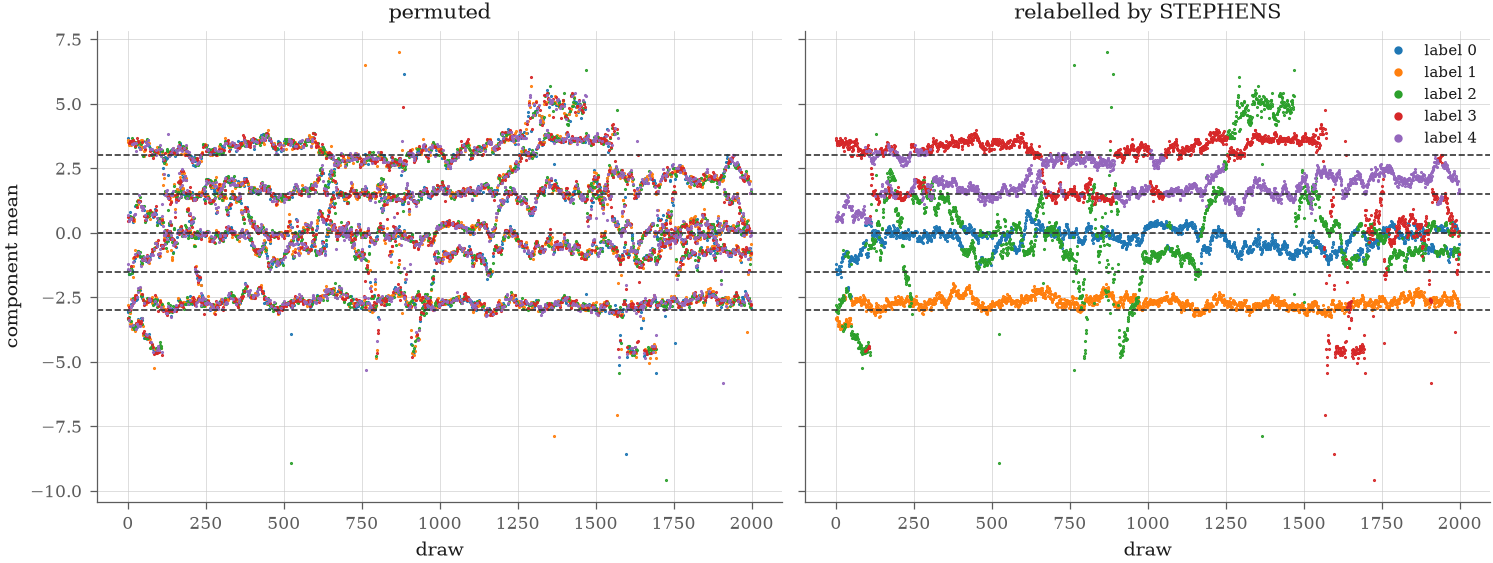

In [6]:
# STEPHENS on the permuted Gibbs chain, and its relabelled means.
chosen = relabel(probabilities=chains["gibbs"]["probabilities"])
raw = chains["gibbs"]["parameters"][:, :, 0]
aligned = permute_parameters(chains["gibbs"]["parameters"], chosen.permutations)[
    :, :, 0
]
with notebook_style():
    figure, axes = plt.subplots(
        1, 2, figsize=(10.0, 3.8), sharey=True, constrained_layout=True
    )
    for axis, values, title in (
        (axes[0], raw, "permuted"),
        (axes[1], aligned, "relabelled by STEPHENS"),
    ):
        for label in range(K):
            axis.plot(values[:, label], ".", markersize=1.0, label=f"label {label}")
        for mean in truth_means:
            axis.axhline(mean, color="0.2", linestyle="--", linewidth=0.8)
        axis.set_title(title, fontsize=10)
        axis.set_xlabel("draw")
    axes[0].set_ylabel("component mean")
    axes[1].legend(fontsize=7, markerscale=6, loc="upper right")
    plt.show()

## The count-pair emission mixture

`emission_mixture/ci`: three components of the joint count-pair family --- a
negative-binomial total and a beta-binomial count of successes out of it ---
over 900 pairs. The family has no conjugate prior, so there is no Gibbs
sampler here; `EmissionMixtureObjective` makes its likelihood differentiable
in log weights and log parameters, and **HMC** (10 steps of 0.02, 200
discarded, 1,000 kept) and **MALA** (steps of 0.01, 1,000 discarded, 4,000
kept) draw from it under the same Gaussian prior of scale 10, each started at
the declared components. The relabelling reads each draw's responsibilities
from `allocation_draws`, the one path every emission family shares.

In [7]:
# The declared count-pair instance and its one draw under the declared seed.
counts_declared = fixture("emission_mixture", "ci").params
counts = simulate_emission_mixture(counts_declared)
pairs = counts.observations
truth_family = counts_declared.components


def build(named):
    # The joint count-pair family at named parameters, one value per component.
    return CountPairEmission(
        named["dispersion"], named["mean"], named["alpha"], named["beta"], joint=True
    )


# The mixture's posterior under an isotropic prior in unconstrained coordinates.
count_posterior = hmc.WithGaussianPrior(
    EmissionMixtureObjective(pairs, truth_family, build), 10.0
)
# The Bayes rule at the generating parameters, the accuracy's ceiling.
count_bayes = responsibilities(
    torch.as_tensor(pairs),
    torch.log(torch.as_tensor(counts_declared.weights)),
    truth_family,
).argmax(dim=1)
COUNT_CEILING = float((count_bayes.numpy() == counts.labels).mean())

opened = time.perf_counter()
count_hmc = hmc.sample(
    count_posterior,
    torch.Generator().manual_seed(964),
    1_000,
    step_size=0.02,
    n_steps=10,
    burn_in=200,
)
count_hmc_seconds = time.perf_counter() - opened
opened = time.perf_counter()
count_mala = mala(
    count_posterior,
    torch.Generator().manual_seed(964),
    4_000,
    step_size=0.01,
    burn_in=1_000,
)
count_mala_seconds = time.perf_counter() - opened


def count_chain(draws, rng):
    # One chain's draws as arrays, their responsibilities, and random namings.
    named = [count_posterior.constrain(theta) for theta in draws]
    weights = np.stack([np.exp(n["log_weight"].detach().numpy()) for n in named])
    columns = {
        key: np.stack([n[key].detach().numpy() for n in named])
        for key in ("mean", "dispersion", "alpha", "beta")
    }
    families = [
        build({key: torch.as_tensor(columns[key][t]) for key in columns})
        for t in range(len(named))
    ]
    drawn = allocation_draws(pairs, np.log(weights), families, rng)
    planted = random_permutations(len(named), weights.shape[1], rng)
    parameters = np.stack(
        [
            columns["mean"],
            columns["dispersion"],
            columns["alpha"],
            columns["beta"],
            weights,
        ],
        axis=2,
    )
    return {
        "planted": planted,
        "parameters": permute_parameters(parameters, planted),
        "probabilities": permute_probabilities(drawn.probabilities, planted),
        "allocations": permute_allocations(drawn.allocations, planted),
        "log_posterior": np.array([-float(count_posterior(theta)) for theta in draws]),
    }


def count_scores(estimate: np.ndarray) -> np.ndarray:
    # SJW's complete-data score of every pair in every component.
    family = CountPairEmission(
        estimate[:, 1], estimate[:, 0], estimate[:, 2], estimate[:, 3], joint=True
    )
    weight = np.log(np.clip(estimate[:, 4], 1e-300, None))
    return family.log_density(torch.as_tensor(pairs)).numpy() + weight


count_chains = {
    "hmc": count_chain(count_hmc.theta, np.random.default_rng(3)),
    "mala": count_chain(count_mala.theta, np.random.default_rng(4)),
}
print(
    f"hmc {count_hmc_seconds:.1f} s, acceptance {count_hmc.acceptance_rate:.3f}; "
    f"mala {count_mala_seconds:.1f} s, acceptance {count_mala.acceptance_rate:.3f}"
)
count_truth = truth_family.mean.numpy().reshape(-1)
for name, c in count_chains.items():
    print(f"{name} chain, Bayes-rule ceiling {COUNT_CEILING:.3f}")
    print(table(evaluate(c, counts.labels, count_truth, count_scores)))
    print()

hmc 23.2 s, acceptance 0.910; mala 27.0 s, acceptance 0.983
hmc chain, Bayes-rule ceiling 0.956


| method | seconds | passes | planted recovery | accuracy | max mean error |
|---|---|---|---|---|---|
| stephens | 0.14 | 2 | 1.000 | 0.953 | 2.631 |
| ecr | 0.01 | 1 | 1.000 | 0.953 | 2.631 |
| ecr-iterative-1 | 0.02 | 2 | 1.000 | 0.953 | 2.631 |
| ecr-iterative-2 | 0.06 | 2 | 1.000 | 0.953 | 2.631 |
| pra | 0.00 | 1 | 1.000 | 0.953 | 2.631 |
| sjw | 0.11 | 2 | 1.000 | 0.953 | 2.631 |
| aic | 0.00 | 1 | 1.000 | 0.953 | 2.631 |

mala chain, Bayes-rule ceiling 0.956


| method | seconds | passes | planted recovery | accuracy | max mean error |
|---|---|---|---|---|---|
| stephens | 1.02 | 2 | 1.000 | 0.951 | 2.784 |
| ecr | 0.04 | 1 | 1.000 | 0.951 | 2.784 |
| ecr-iterative-1 | 0.12 | 2 | 1.000 | 0.951 | 2.784 |
| ecr-iterative-2 | 0.28 | 2 | 1.000 | 0.951 | 2.784 |
| pra | 0.01 | 1 | 1.000 | 0.951 | 2.784 |
| sjw | 0.72 | 3 | 1.000 | 0.951 | 2.784 |
| aic | 0.00 | 1 | 1.000 | 0.951 | 2.784 |



## Reading the tables

**The count-pair mixture is where relabelling is settled.** Its three
components are separated (means 30, 80 and 200 per pair), and every method
restores every planted permutation on both chains: accuracy 0.953 (HMC) and
0.951 (MALA) against the Bayes rule's 0.956, and the relabelled means within
2.8 of the generating ones. The methods differ only in cost, from under 0.01 s
(AIC, PRA, ECR) to 1.0 s (STEPHENS on 4,000 draws).

**On the overlapping Gaussian mixture the chain renames the components
itself, and the methods part.** Before any planted permutation, 53% of the
Gibbs draws and 65% of the HMC draws hold their components out of the chain's
most frequent order, so planted recovery there measures agreement with a
naming the chain did not keep, not correctness: 0.23 (STEPHENS) to 0.47 (PRA,
AIC) on the Gibbs chain. Against the generating components, the Gibbs chain's
relabelled allocation reaches 0.600 to 0.660 against the ceiling of 0.688,
highest under ECR-ITERATIVE-1, ECR-ITERATIVE-2 and SJW. Its relabelled means
land within 0.57 of the generating means under PRA and AIC and within 1.26
under STEPHENS: in one channel at equal scales the mean orders the components,
while the allocation probabilities STEPHENS reads are shared between
neighbours.

**The HMC chain sits in another mode, which no relabelling repairs.** Its
effective sample sizes are 5 to 19 over 2,000 draws, and every method's
accuracy is 0.478 to 0.578 against the ceiling of 0.688. Relabelling puts the
draws a sampler produced in one naming; it does not move them.

## Further work

- A sampler for a count family with no conjugate prior that draws
  allocations, so the ECR family reads drawn rather than simulated
  allocations on the count-pair chain: issue #966.
- The pivotal-unit relabelling of Egidi et al. (2018) and the data-based
  method of Rodriguez & Walker (2014) are not implemented: issue #966.